# Health checks during float operation period

In [ ]:
import os

import numpy as np
import pandas as pd
import datetime

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from emapy.src.readwrite import read_vitals, read_velocity

In [13]:
savefig = True

In [3]:
cruise_id = 'sofe'
float_ids = ['f10761', 'f10762', 'f10763']
float_colors = {'f10761': 'tab:orange', 'f10762': 'tab:pink', 'f10763': 'tab:green'}

In [ ]:
repodir = os.path.dirname(os.path.abspath(''))
print('Repository: ', repodir)
datadir = os.path.join(repodir, 'data')
figsdir = os.path.join(repodir, 'figs')


Repository:  /home/jjmeijer/Repos/ema-seir-pf


In [5]:
def filedirs(float_id):
    filedirs = {
        # 'raw': os.path.join(datadir, cruise_id, float_id, 'raw'),
        # 'proc': os.path.join(datadir, cruise_id, float_id, 'proc'),
        'dec': os.path.join(datadir, cruise_id, float_id, 'proc', 'dec'),
        'vel': os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')}
    return filedirs

## Read vitals

In [ ]:
# read all vitals files
vitals = {}
for float_id in float_ids:
    vitals[float_id] = {}
    files = [os.path.join(filedirs(float_id)['dec'], file) for file in sorted(os.listdir(filedirs(float_id)['dec'])) if file.endswith('vitals_log.csv')]
    for filename in files:
        profile_no = os.path.basename(filename).split('.')[1]
        vitals[float_id][profile_no] = read_vitals(filename)

In [16]:
# combile all profiles in 1 dataframe
vitals_combined = {}
for float_id in float_ids:
    vitals_combined[float_id] = pd.DataFrame()
    profile_nos = [int(key) for key in vitals[float_id].keys()][2:]
    for profile_no in profile_nos:
        vitals_combined[float_id] = pd.concat([vitals_combined[float_id], vitals[float_id]['%03d' %profile_no]])

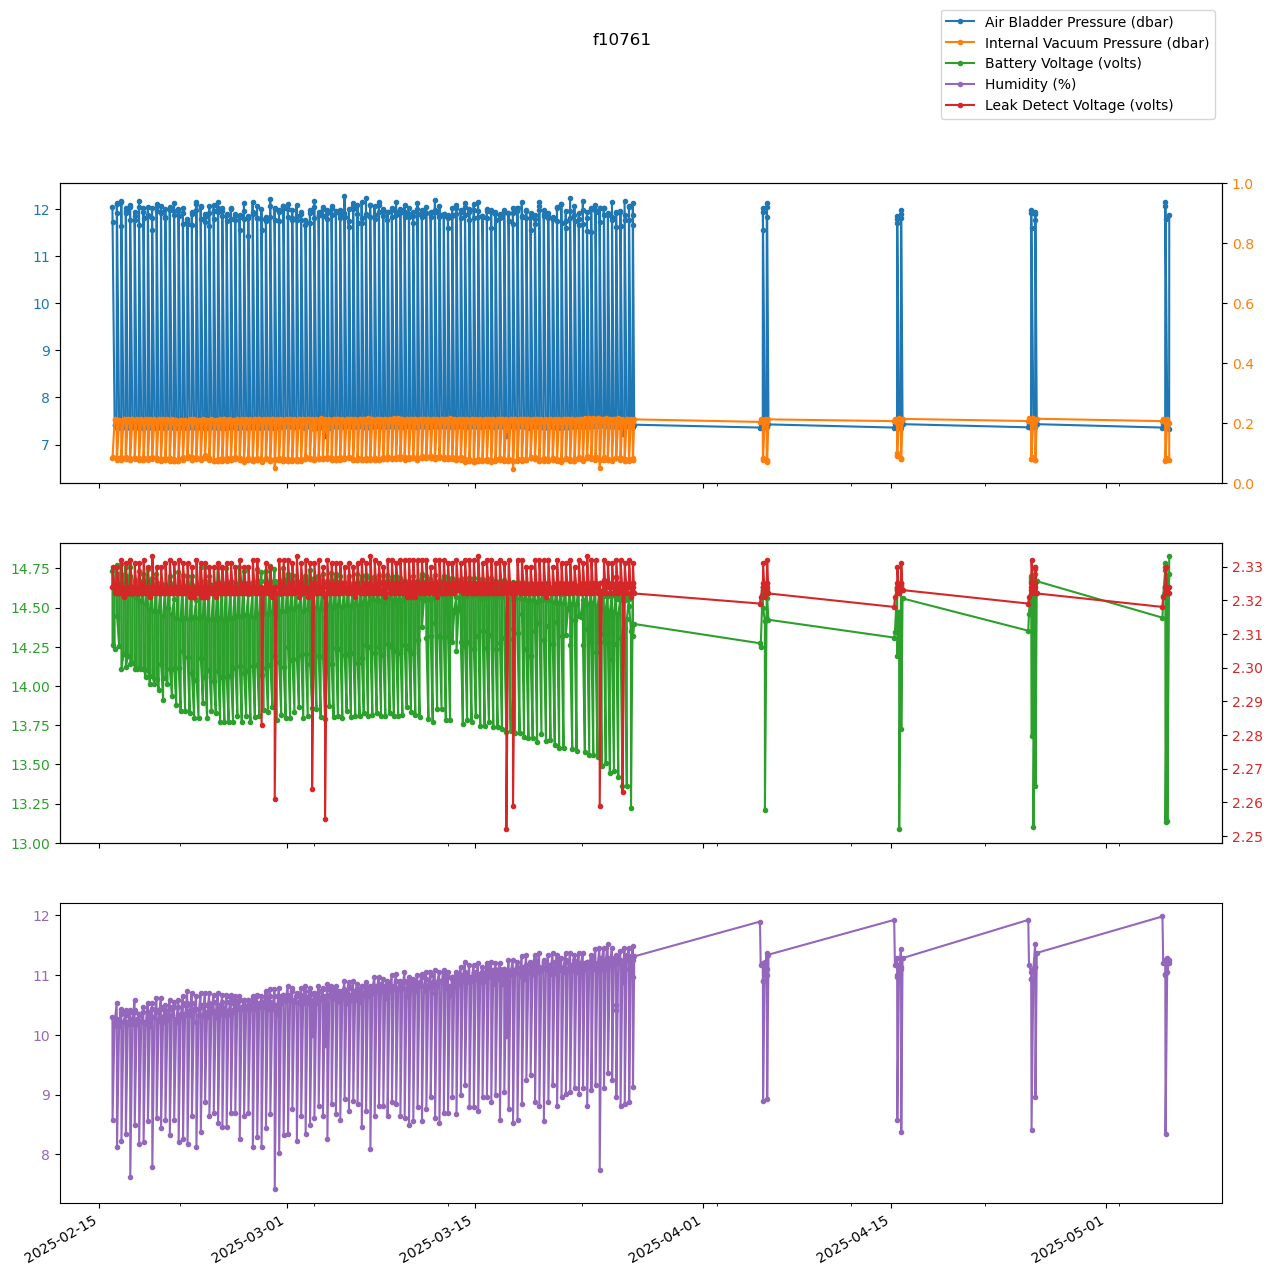

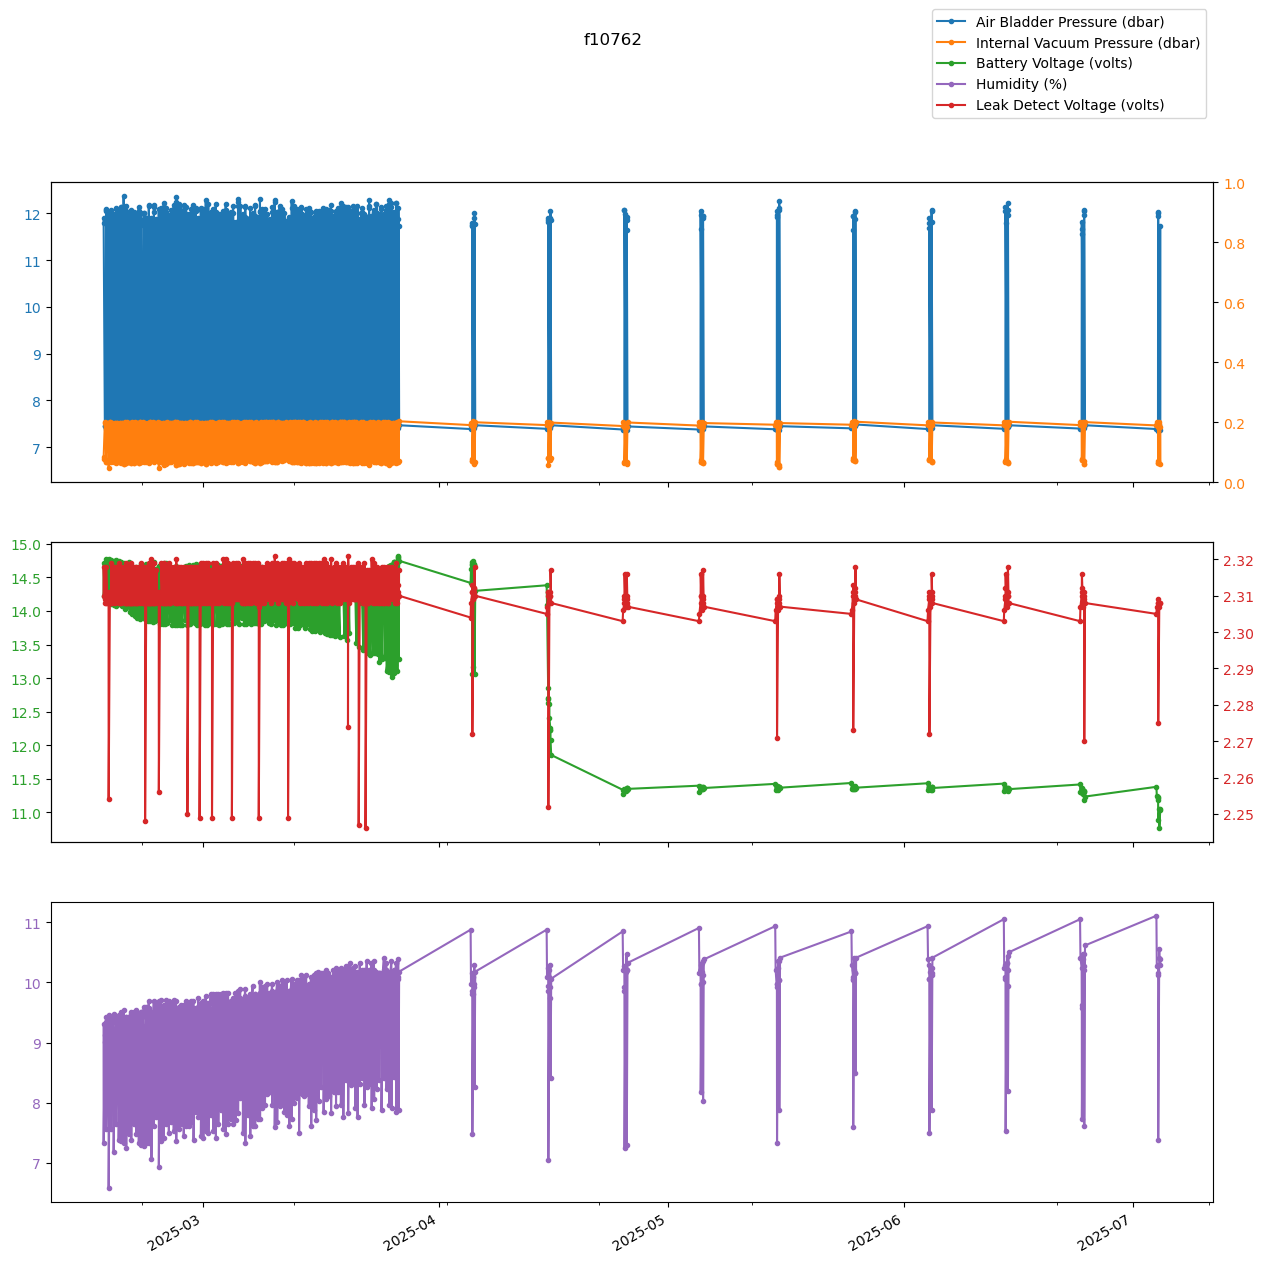

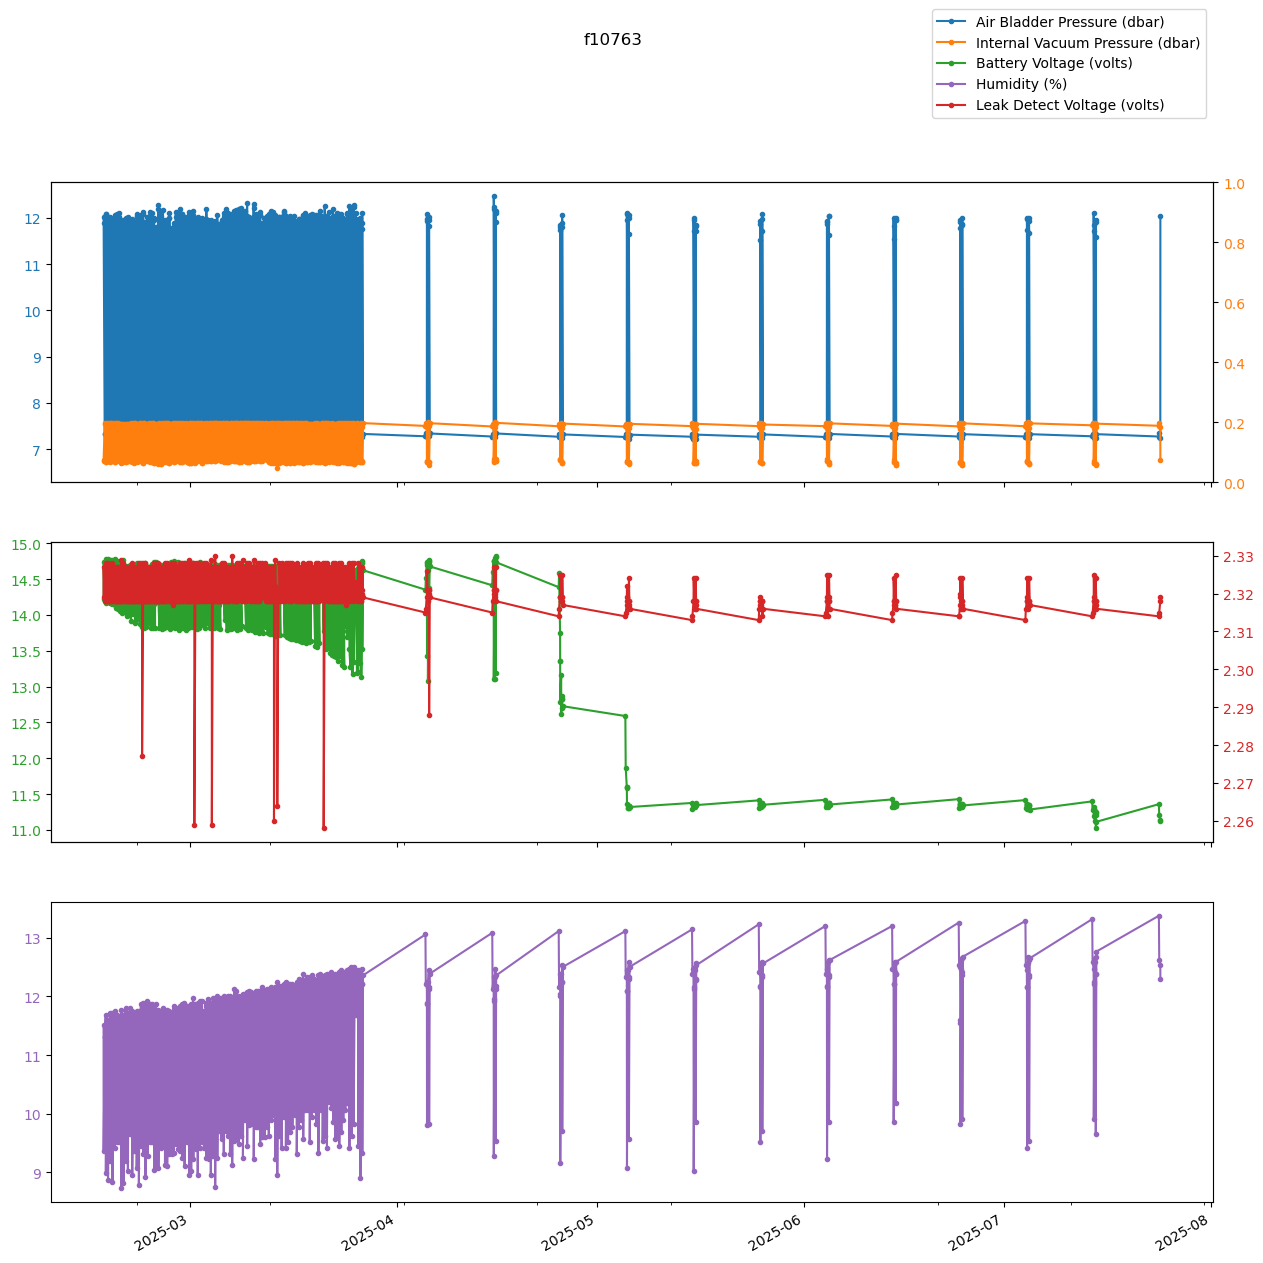

In [17]:
colors = list(mcolors.TABLEAU_COLORS.keys())
for float_id in float_ids:

    fig, ax = plt.subplots(nrows=3, figsize=(15,15), sharex=True)

    vitals_combined[float_id].plot(ax=ax[0], y='Air Bladder Pressure (dbar)', color=colors[0], marker='.', legend=False)
    ax[0].tick_params(axis='y', labelcolor=colors[0])
    ax1 = ax[0].twinx()
    vitals_combined[float_id].plot(ax=ax[0], y='Internal Vacuum Pressure (dbar)', color=colors[1], marker='.', legend=False)
    ax1.tick_params(axis='y', labelcolor=colors[1])

    vitals_combined[float_id].plot(ax=ax[1], y='Battery Voltage (volts)', color=colors[2], marker='.', legend=False)
    ax[1].tick_params(axis='y', labelcolor=colors[2])
    ax2 = ax[1].twinx()
    vitals_combined[float_id].plot(ax=ax2, y='Leak Detect Voltage (volts)', color=colors[3], marker='.', legend=False)
    ax2.tick_params(axis='y', labelcolor=colors[3])

    vitals_combined[float_id].plot(ax=ax[2], y='Humidity (%)', color=colors[4], marker='.', legend=False)
    ax[2].tick_params(axis='y', labelcolor=colors[4])

    fig.legend(bbox_to_anchor=(0.9, 1.))
    fig.suptitle(float_id)

    if savefig:
        fig.savefig(os.path.join(figsdir, '02_vitals_%s.png' %float_id))

## Read buoyancy position, ascent and descent rates

In [14]:
# define pressure bins
minp, maxp, dp = 0, 2000, 4
pressure_bins = np.linspace(minp, maxp, int((maxp-minp)/dp)+1)

# velfiles = [os.path.join(vel_filedir, file) for file in sorted(os.listdir(vel_filedir)) if file.endswith('.txt')]

descents = {}
ascents = {}
for float_id in float_ids:
    descents[float_id] = {}
    ascents[float_id] = {}

    files = [os.path.join(filedirs(float_id)['vel'], file) for file in sorted(os.listdir(filedirs(float_id)['vel'])) if file.endswith('.txt')]


    profiles, t, S = [], [], []
    u1, v1, u2, v2 = [], [], [], []
    lat, lon, time = [], [], []
    for filename in files:
        # print(os.path.basename(filename))
        header, columns, units, descent_data, ascent_data = read_velocity(filename)

        # load data in dataframe and convert to timestamp to datetime type
        df_descent = pd.DataFrame(data=descent_data, columns=columns)
        df_descent.index = pd.to_datetime(df_descent['timestamp'], unit='s', origin='unix')
        df_descent = df_descent.drop(columns=['timestamp'])
        
        df_ascent = pd.DataFrame(data=ascent_data, columns=columns)
        df_ascent.index = pd.to_datetime(df_ascent['timestamp'], unit='s', origin='unix')
        df_ascent = df_ascent.drop(columns=['timestamp'])

        # store dataframe in dict
        profile_no = os.path.basename(filename).split('-')[2]
        descents[float_id][profile_no] = df_descent
        ascents[float_id][profile_no] = df_ascent
        
        # # categorize pressure values into defined  bins
        # df_descent['pressure_bin'] = pd.cut(df_descent['P'], bins=pressure_bins)

        # # group the 'pressure_bin' and calculate the average temperature within each bin
        # df_descent_bin = df_descent.groupby('pressure_bin', observed=False).mean().reset_index()

        # profiles.append(int(profile_no))
        # t.append(df_descent_bin['T'].values)
        # S.append(df_descent_bin['S'].values)
        # u1.append(df_descent_bin['u1'].values)
        # v1.append(df_descent_bin['v1'].values)
        # u2.append(df_descent_bin['u2'].values)
        # v2.append(df_descent_bin['v2'].values)

        # lat.append(float(header['Descent GPS LAT'][0]))
        # lon.append(float(header['Descent GPS LON'][0]))
        # time.append(datetime.datetime.fromtimestamp(float(header['Descent GPS Timestamp'][0])))

    # pressure = [val.mid for val in df_descent_bin.pressure_bin]
    # temperature, salinity = np.asarray(t), np.asarray(S)
    # u1, v1, u2, v2 = np.asarray(u1), np.asarray(v1), np.asarray(u2), np.asarray(v2)

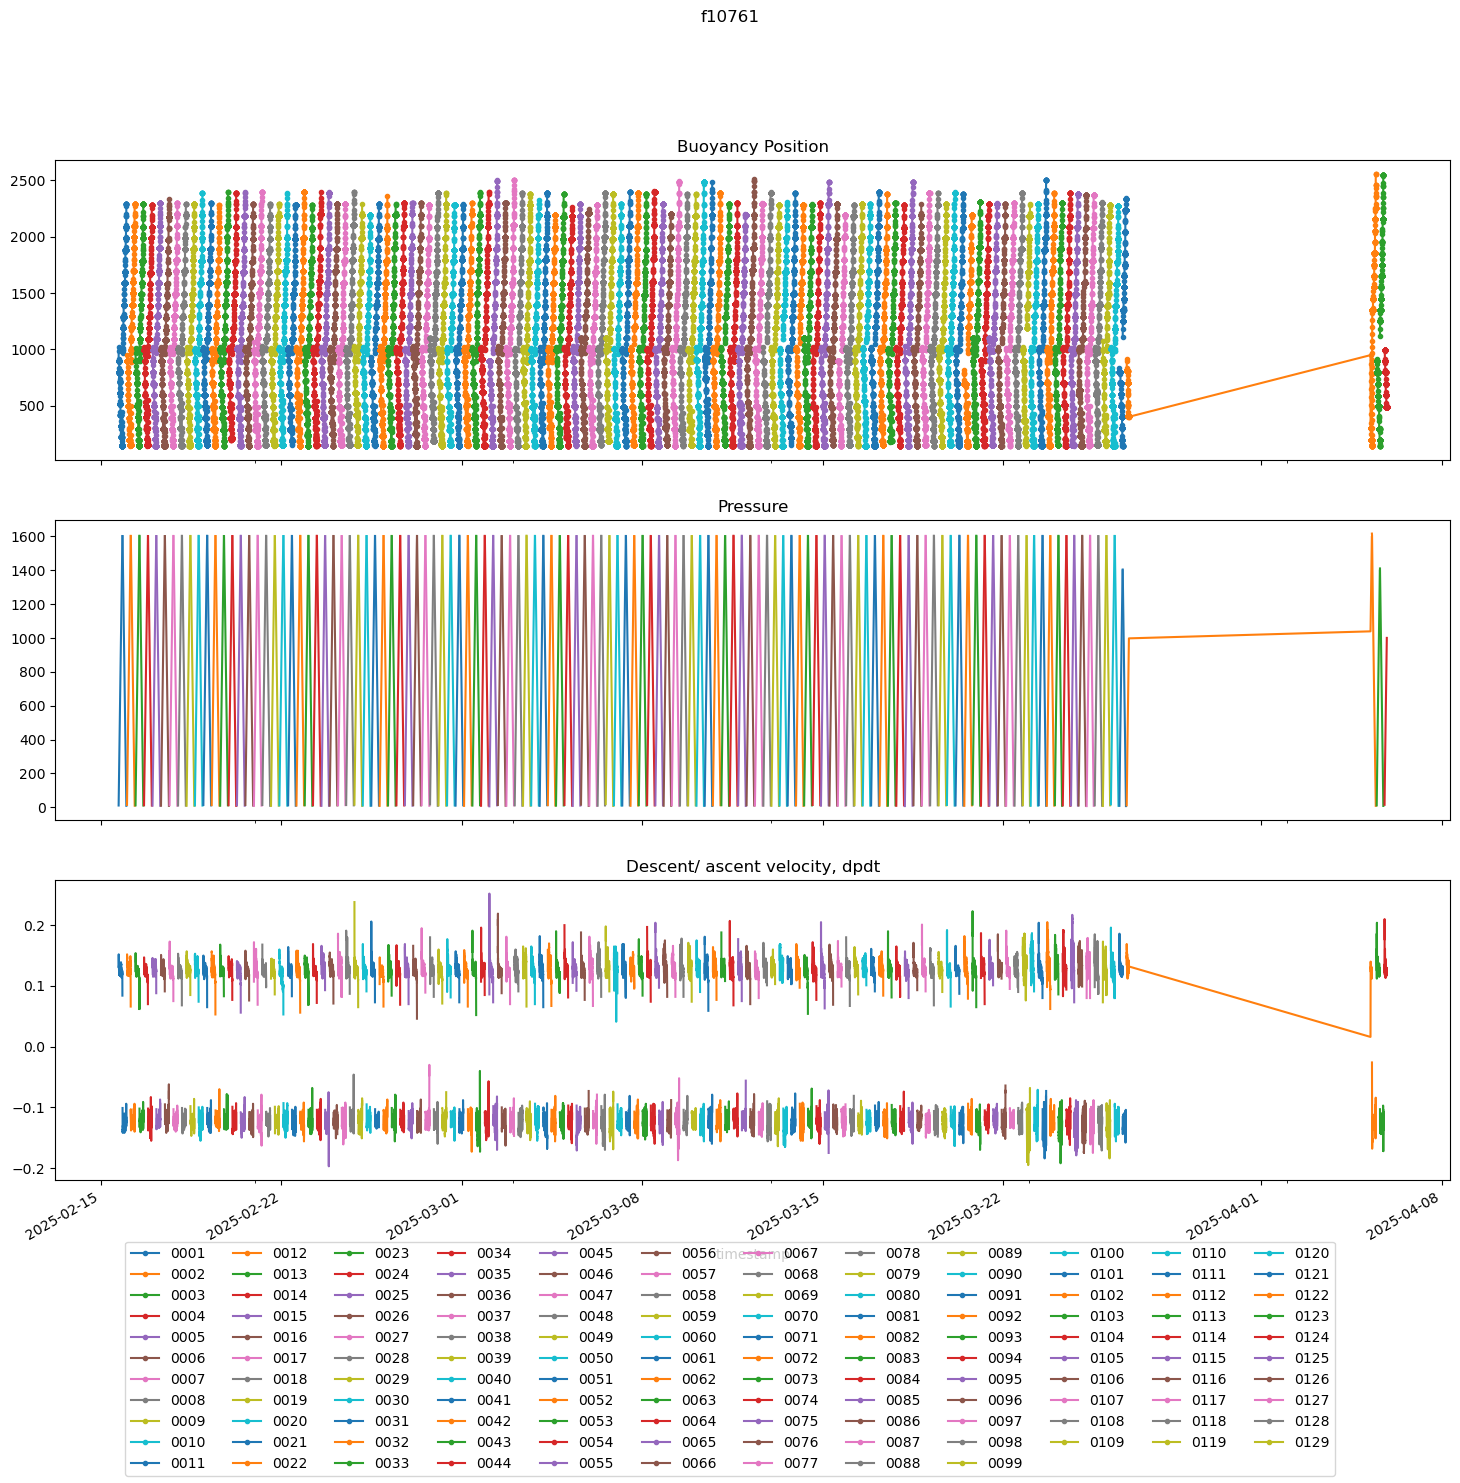

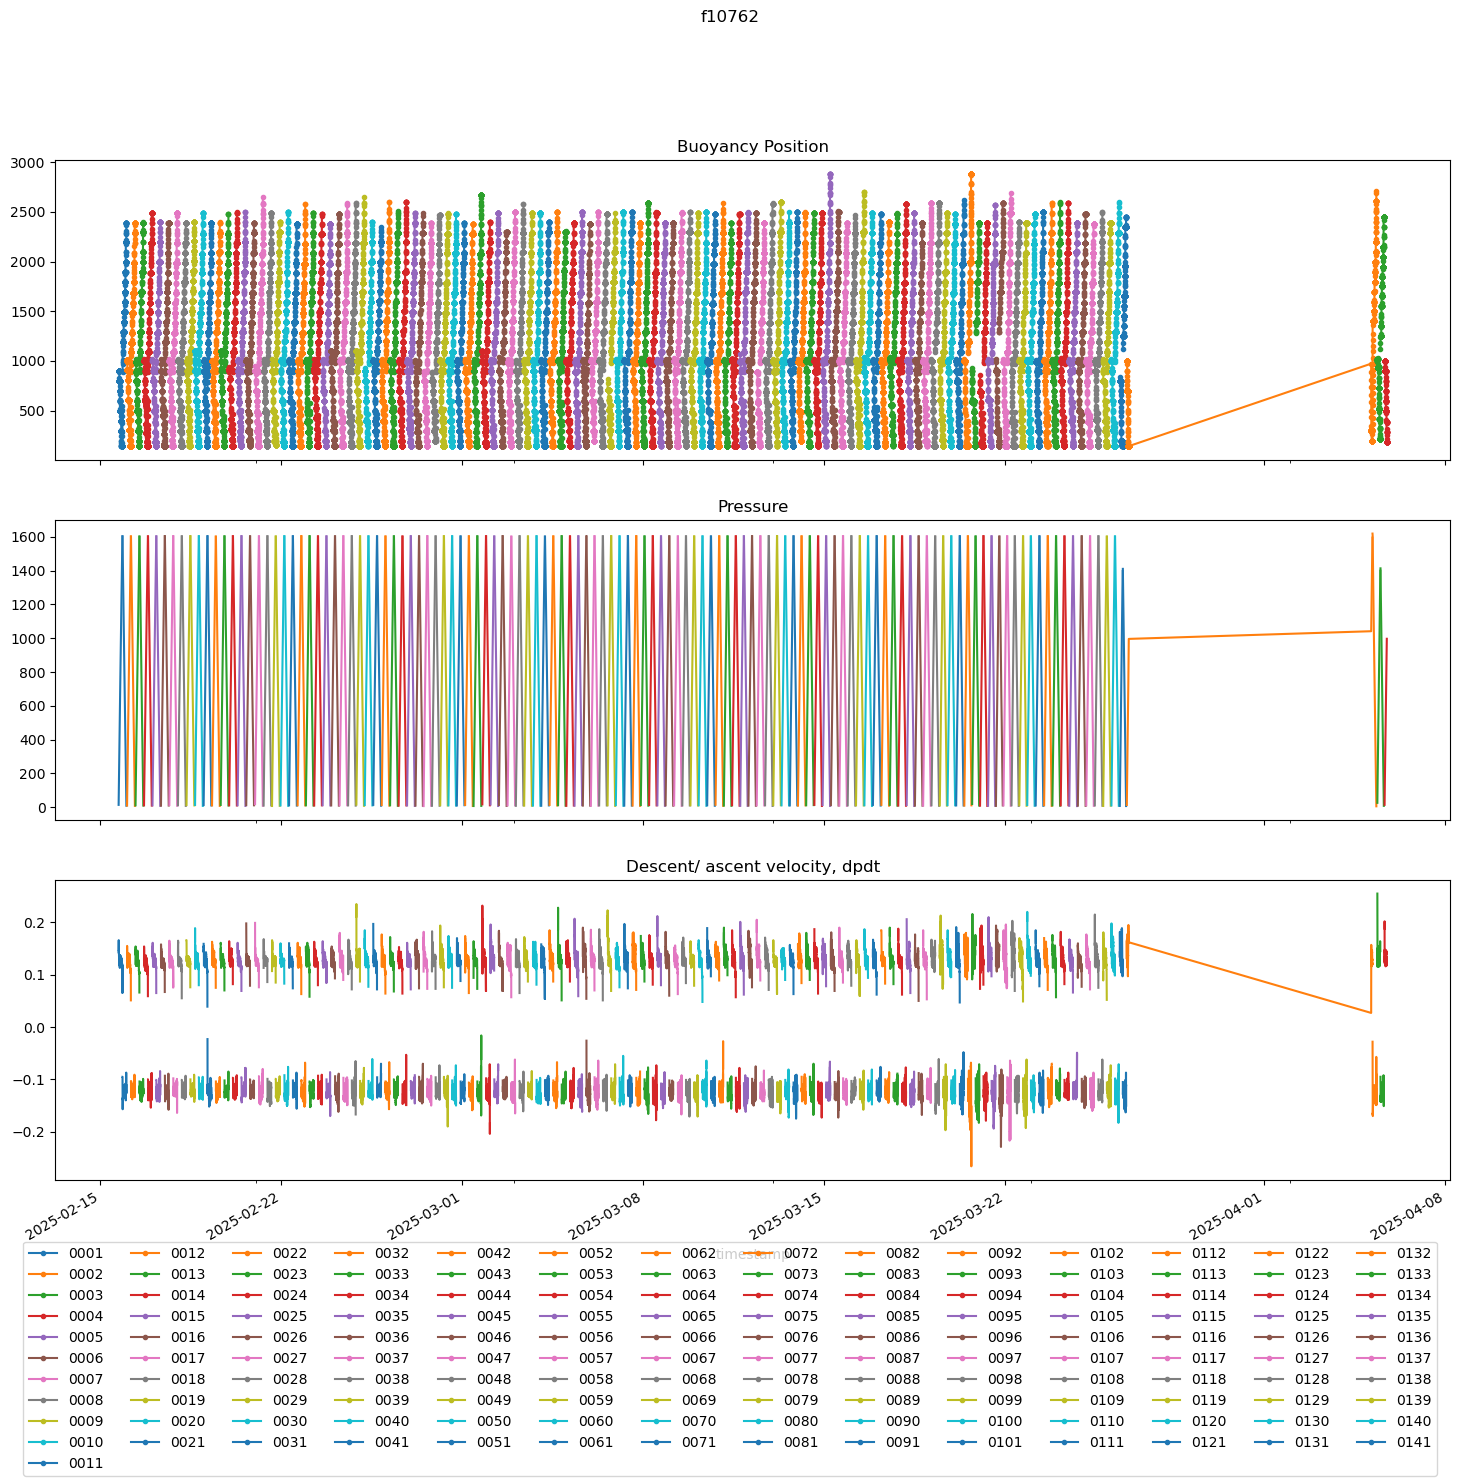

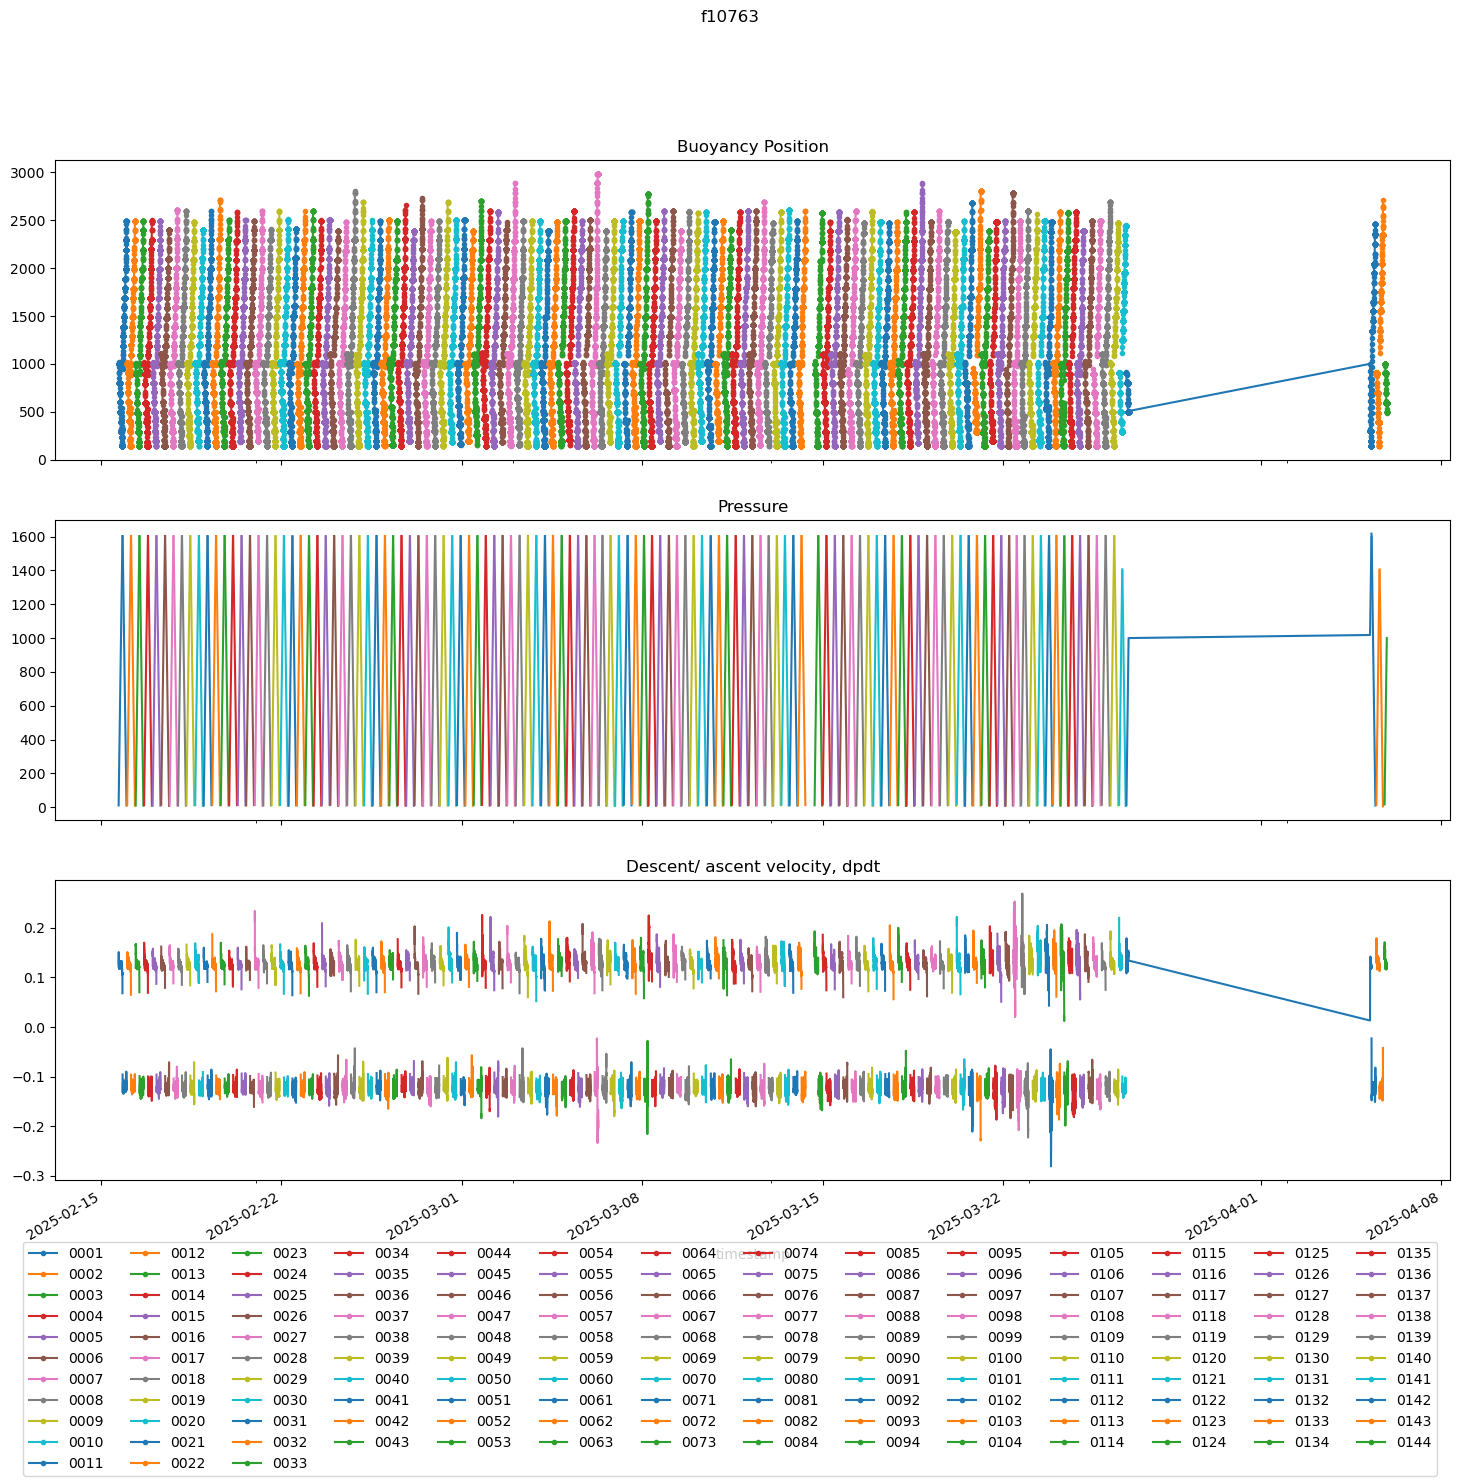

In [ ]:
start_date = '2025-02-15'
end_date = '2025-04-15'

for float_id in float_ids:

    fig, ax = plt.subplots(nrows=3, figsize=(18,15), sharex=True)
    i=0
    for ((pf_no, descent), (pf_no2, ascent)) in zip(descents[float_id].items(), ascents[float_id].items()):
        # print(pf_no, descent['buoy_pos'][0], descent['timestamp'][0])

        descent[(descent.index > start_date) & (descent.index < end_date)].plot(ax=ax[0], y='buoy_pos', label='', legend=False, marker='.')
        ap = ascent[(ascent.index > start_date) & (ascent.index < end_date)].plot(ax=ax[0], y='buoy_pos', legend=False, label=pf_no, marker='.', color=colors[i])
        ax[0].set_title('Buoyancy Position')
        descent[(descent.index > start_date) & (descent.index < end_date)].plot(ax=ax[1], y='P', label='', legend=False)
        ascent[(ascent.index > start_date) & (ascent.index < end_date)].plot(ax=ax[1], y='P', label='', legend=False, color=colors[i])
        ax[1].set_title('Pressure')
        descent[(descent.index > start_date) & (descent.index < end_date)].plot(ax=ax[2], y='dpdt', label='', legend=False)
        ascent[(ascent.index > start_date) & (ascent.index < end_date)].plot(ax=ax[2], y='dpdt', label='', legend=False, color=colors[i])
        ax[2].set_title('Descent/ ascent velocity, dpdt')

        if i < len(colors)-1:
            i+=1
        else:
            i=0

    fig.legend(loc='lower center', ncols=int(len(descents[float_id].keys())/len(colors)))#bbox_to_anchor=(1.0, .8)
    fig.suptitle(float_id)

    if savefig:
        fig.savefig(os.path.join(figsdir, '02_descent-ascent-rates_%s.png' %float_id))
# ax[0].legend(loc='upper center')